# Adaptive Boosting (AdaBoost) Tutorial

AdaBoost (Adaptive Boosting) is a sequential ensemble method that combines multiple weak learners (usually decision stumps - trees with a depth of 1) to build a strong classifier. It works by assigning weights to each training instance, increasing the weights of misclassified instances in subsequent iterations so that the next weak learner focuses more on hard cases.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set_theme(style='whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# Load the Pima Indians Diabetes Dataset
df = pd.read_csv('../../Datasets/diabetes.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')

Train set shape: (614, 8)
Test set shape: (154, 8)


In [4]:
# Instantiate and train the AdaBoost Classifier
# The default base estimator is a DecisionTreeClassifier with max_depth=1 (a decision stump)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

# Predict probabilities and classes
y_pred = ada.predict(X_test)
y_pred_proba = ada.predict_proba(X_test)[:, 1]

print(f'AdaBoost Model Train Accuracy: {ada.score(X_train, y_train):.4f}')
print(f'AdaBoost Model Test Accuracy: {ada.score(X_test, y_test):.4f}')

AdaBoost Model Train Accuracy: 0.8192
AdaBoost Model Test Accuracy: 0.7922


In [5]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

Confusion Matrix:
[[86 14]
 [18 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       100
           1       0.72      0.67      0.69        54

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154

ROC-AUC Score: 0.8284


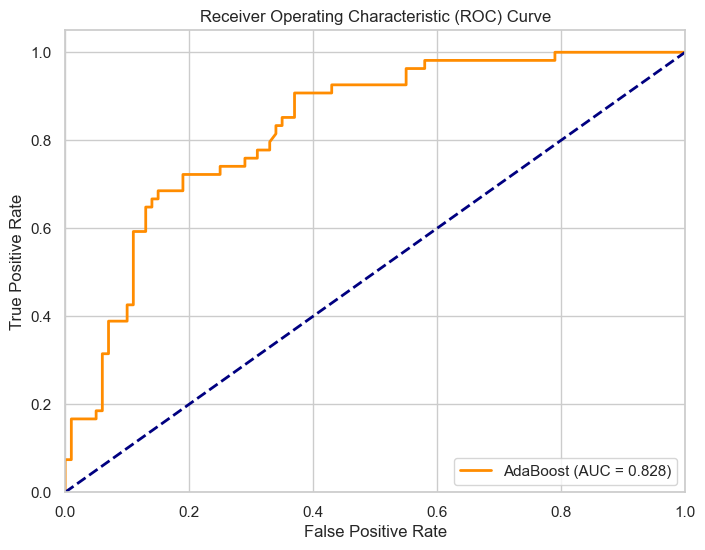

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AdaBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

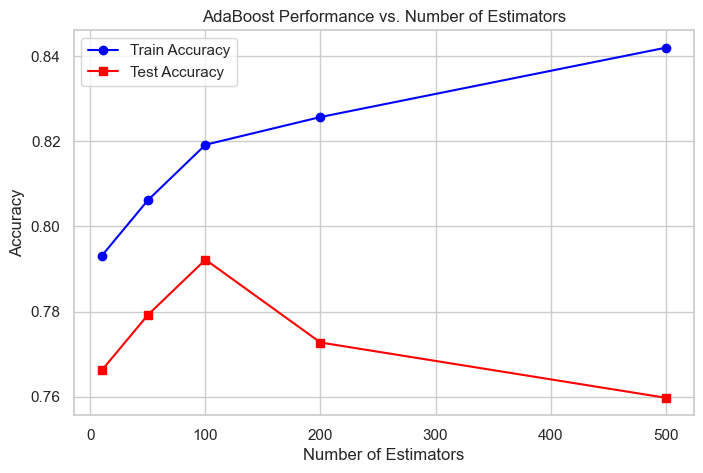

In [7]:
estimators_list = [10, 50, 100, 200, 500]
train_scores = []
test_scores = []

for n_est in estimators_list:
    model = AdaBoostClassifier(n_estimators=n_est, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(estimators_list, train_scores, marker='o', label='Train Accuracy', color='blue')
plt.plot(estimators_list, test_scores, marker='s', label='Test Accuracy', color='red')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('AdaBoost Performance vs. Number of Estimators')
plt.legend()
plt.show()

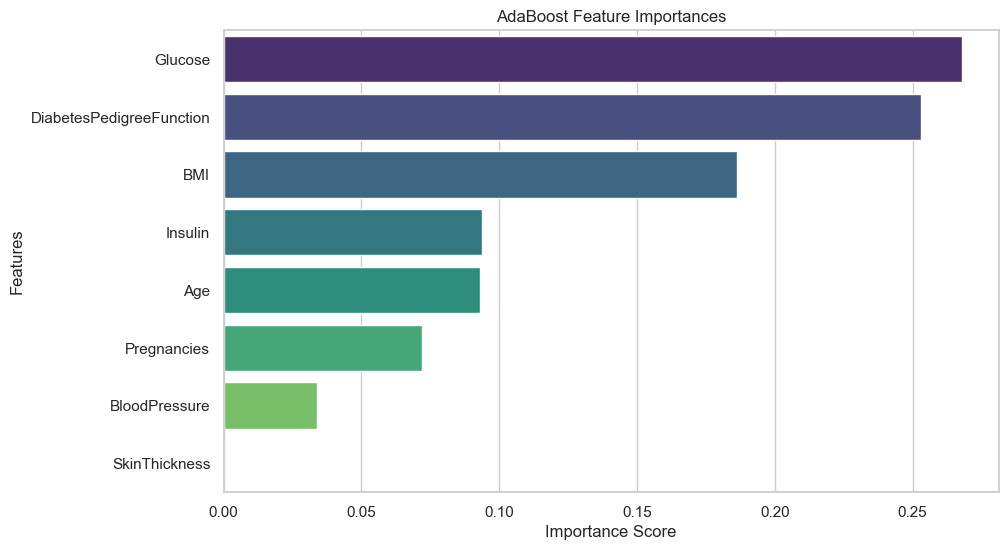

In [8]:
importances = ada.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('AdaBoost Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Key Takeaways:
1. AdaBoost adaptively focuses on harder instances, which often yields a significant improvement over simple decision trees.
2. It is sensitive to noisy data and outliers because it continuously attempts to fit them by increasing their weights.
3. Feature importances help us understand which attributes contribute the most to the adaptive splits.